### Plotting the result

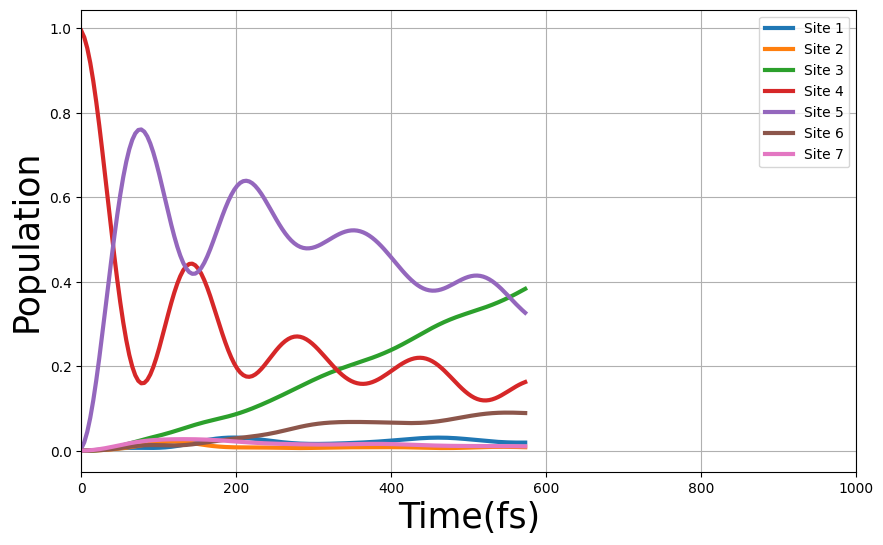

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取Excel文件
df = pd.read_excel('multiset_64bd.xlsx')
# df = pd.read_excel('/curie-home/zengjj/Renormalizer/test/fmo_benchmark.xlsx')

# 提取数据
x = np.arange(0,df.shape[0],1)
x = x * 160 * 0.024188843265

y_columns = df.iloc[:, 0:7]  # 第1-7列作为y坐标

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制七条线
for i in range(0,7):
    plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

# 添加图表元素
plt.xlabel('Time(fs)',size = 25)
plt.ylabel('Population',size = 25)
plt.xlim((0, 1000))
plt.title('')
plt.legend()
plt.grid(True)

# 显示图表
plt.show()

### Plotting the error

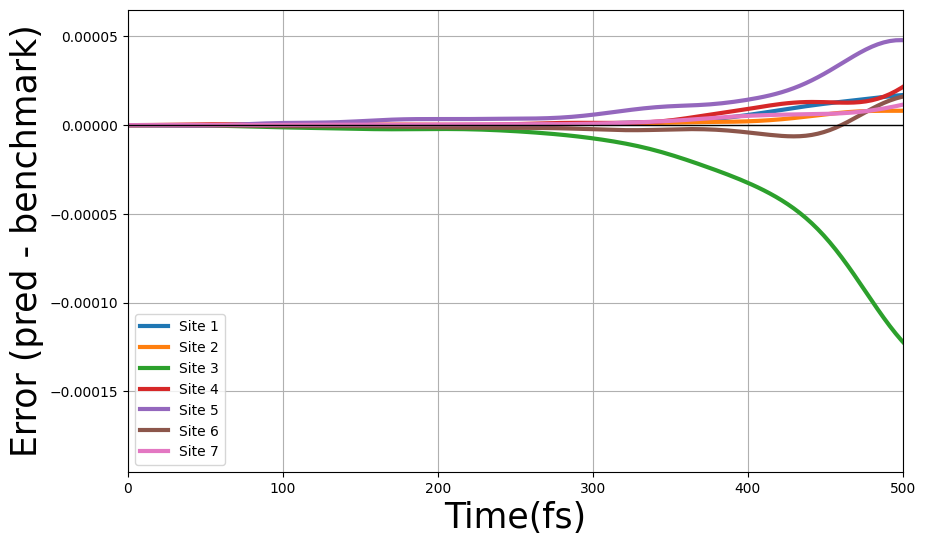

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取 benchmark（行数更多）
df_bm = pd.read_excel('../plot_2026_2/fmo_benchmark_128bd.xlsx')

# 时间步长（与你第一张图一致）
dt = 160 * 0.024188843265

# pred(你的结果) 的时间轴：用第一张图里的 df（确保第一个 block 已运行）
x_pred = np.arange(df.shape[0]) * dt
y_pred = df.iloc[:, 0:7].to_numpy()

# benchmark 的时间轴
x_bm = np.arange(df_bm.shape[0]) * dt
y_bm = df_bm.iloc[:, 0:7].to_numpy()

# 将 benchmark 插值到 pred 的时间点上，然后算误差：pred - benchmark
y_bm_on_pred = np.column_stack([
    np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(7)
])
err = y_pred - y_bm_on_pred
# 如果你想画绝对误差：err = np.abs(err)

# 画误差图
plt.figure(figsize=(10, 6))
for i in range(7):
    plt.plot(x_pred, err[:, i], label=f'Site {i+1}', linewidth=3)

plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Time(fs)', size=25)
plt.ylabel('Error (pred - benchmark)', size=25)
plt.xlim((0, 500))
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

Benchmark : singleset_256bd.xlsx
  行数=252, 列数=7, dt=3.8702 fs
  时间范围: 0 ~ 971.4 fs

  [已绘制] singleset  ($\chi'=64$)
    时间范围: 0 ~ 971.4 fs,  最大MAE=1.6425e-03,  均值MAE=4.1928e-04
  [已绘制] multiset  ($\chi'=64$)
    时间范围: 0 ~ 963.7 fs,  最大MAE=8.9646e-04,  均值MAE=1.4197e-04
  [已绘制] multiset_old  ($\chi'=64$)
    时间范围: 0 ~ 963.7 fs,  最大MAE=9.3249e-04,  均值MAE=2.1422e-04
  [已绘制] singleset  ($\chi'=128$)
    时间范围: 0 ~ 971.4 fs,  最大MAE=2.4637e-04,  均值MAE=4.3075e-05
  [已绘制] multiset   ($\chi'=128$)
    时间范围: 0 ~ 963.7 fs,  最大MAE=1.2527e-04,  均值MAE=2.1453e-05

✅ 已保存: FMO_MAE_vs_256bd.png


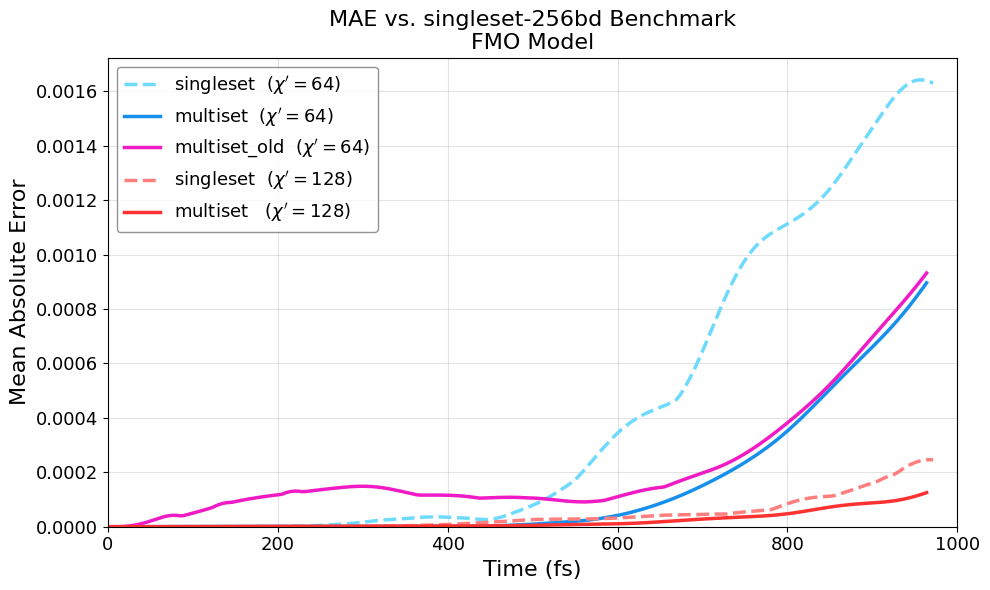

In [9]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_error():
    """
    以 singleset_256bd.xlsx 为 benchmark，
    计算其余三个文件的 Mean Absolute Error 并绘图。
    """

    # ============================================================
    # 1. 路径配置（只需修改此处）
    # ============================================================
    test_dir = "."   # ← 修改为你的文件夹路径，若在同目录则保持 "."

    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    # 需要对比的三个文件（按 bond dimension 从小到大排列）
    data_files = [
        # os.path.join(test_dir, "singleset_32bd.xlsx"),
        # os.path.join(test_dir, "multiset_32bd.xlsx"),
        # os.path.join(test_dir, "multiset_32bd_old.xlsx"),
        os.path.join(test_dir, "singleset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd.xlsx"),
        os.path.join(test_dir, "multiset_64bd_old.xlsx"),
        os.path.join(test_dir, "singleset_128bd.xlsx"),
        os.path.join(test_dir, "multiset_128bd.xlsx"),
    ]

    # ============================================================
    # 2. 样式配置：(标签, 颜色, 线型, 线宽)
    # ============================================================
    styles = {
        # "singleset_32bd.xlsx":  ("singleset  ($\\chi'=32$)",  "#4df01b", "--",  2.5),
        # "multiset_32bd.xlsx":  ("multiset  ($\\chi'=32$)",  "#2ca02c", "-",  2.5),
        # "multiset_32bd_old.xlsx":  ("multiset_old  ($\\chi'=64$)",  "#4df01b", "--",  2.5),
        "singleset_64bd.xlsx":  ("singleset  ($\\chi'=64$)",  "#6ddafe", "--",  2.5),
        "multiset_64bd.xlsx":  ("multiset  ($\\chi'=64$)",  "#1690ec", "-",  2.5),
        "multiset_64bd_old.xlsx":  ("multiset_old  ($\\chi'=64$)",  "#f01bc5", "-",  2.5),
        "singleset_128bd.xlsx": ("singleset  ($\\chi'=128$)", "#ff7e7e", "--",  2.5),
        "multiset_128bd.xlsx":   ("multiset   ($\\chi'=128$)",  "#ff3232", "-", 2.5),
    }

    # ============================================================
    # 3. 时间步长（单位：fs）
    #    dt = 每步原子单位数 × 0.024188843265 fs/a.u.
    #    根据实际步长修改 dt_au
    # ============================================================
    dt_au = 160                          # ← 按需修改
    dt    = dt_au * 0.024188843265       # fs

    # ============================================================
    # 4. 读取 benchmark
    # ============================================================
    if not os.path.exists(benchmark_file):
        raise FileNotFoundError(f"Benchmark 文件未找到: {benchmark_file}")

    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]              # 自动识别列数（FMO 通常为 7 个 site）
    y_bm  = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm  = np.arange(len(y_bm)) * dt

    print(f"Benchmark : singleset_256bd.xlsx")
    print(f"  行数={len(y_bm)}, 列数={n_col}, dt={dt:.4f} fs")
    print(f"  时间范围: 0 ~ {x_bm[-1]:.1f} fs\n")

    # ============================================================
    # 5. 绘图
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    for fpath in data_files:
        if not os.path.exists(fpath):
            print(f"  [跳过] 文件不存在: {fpath}")
            continue

        fname = os.path.basename(fpath)
        label, color, ls, lw = styles.get(fname, (fname, None, "-", 2.0))

        # 读取预测数据
        df_pred = pd.read_excel(fpath, header=None)
        y_pred  = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred  = np.arange(len(y_pred)) * dt

        # 将 benchmark 插值到预测时间轴上
        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])

        # 计算 Mean Absolute Error（对所有 site 取平均）
        mae = np.mean(np.abs(y_pred - y_bm_interp), axis=1)

        ax.plot(x_pred, mae,
                label=label,
                color=color,
                linestyle=ls,
                linewidth=lw)

        print(f"  [已绘制] {label}")
        print(f"    时间范围: 0 ~ {x_pred[-1]:.1f} fs,  "
              f"最大MAE={mae.max():.4e},  均值MAE={mae.mean():.4e}")

    # ============================================================
    # 6. 坐标轴与标注
    # ============================================================
    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("Mean Absolute Error", fontsize=16)
    ax.set_title(
        "MAE vs. singleset-256bd Benchmark\n"
        "FMO Model",
        fontsize=16
    )
    ax.set_xlim(left=0,right=1000)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_MAE_vs_256bd.png", dpi=150)
    print("\n✅ 已保存: FMO_MAE_vs_256bd.png")
    plt.show()


plot_fmo_error()

  singleset  ($\chi'=64$, $dt=160$): 252 steps, max MAE=1.6425e-03, mean MAE=4.1928e-04
  multiset  ($\chi'=64$, $dt=160$): 250 steps, max MAE=8.9646e-04, mean MAE=1.4197e-04
  multiset  ($\chi'=64$, $dt=320$): 125 steps, max MAE=8.6691e-04, mean MAE=1.4116e-04
  multiset  ($\chi'=64$, $dt=80$): 250 steps, max MAE=8.9529e-04, mean MAE=1.4409e-04
  multiset  ($\chi'=64$, $dt=640$): 63 steps, max MAE=8.8410e-04, mean MAE=1.4542e-04
  multiset  ($\chi'=64$, $dt=1280$): 32 steps, max MAE=9.2103e-04, mean MAE=1.5863e-04

Saved: FMO_MAE_64bd_dt_comparison.png


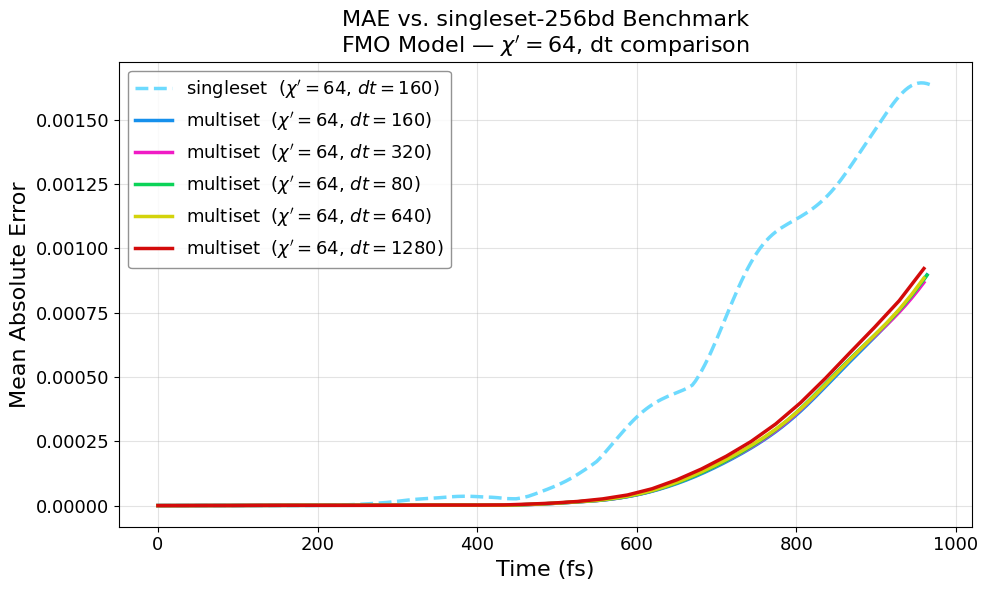

  singleset  ($\chi'=64$, $dt=160$): 252 steps, max MAE=1.6425e-03, mean MAE=4.1928e-04
  multiset  ($\chi'=64$, $dt=160$): 250 steps, max MAE=8.9646e-04, mean MAE=1.4197e-04
  multiset  ($\chi'=64$, $dt=320$): 125 steps, max MAE=8.6691e-04, mean MAE=1.4116e-04
  multiset  ($\chi'=64$, $dt=80$): 250 steps, max MAE=8.9529e-04, mean MAE=1.4409e-04
  multiset  ($\chi'=64$, $dt=640$): 63 steps, max MAE=8.8410e-04, mean MAE=1.4542e-04
  multiset  ($\chi'=64$, $dt=1280$): 32 steps, max MAE=9.2103e-04, mean MAE=1.5863e-04

Saved: FMO_MAE_64bd_dt_comparison.png


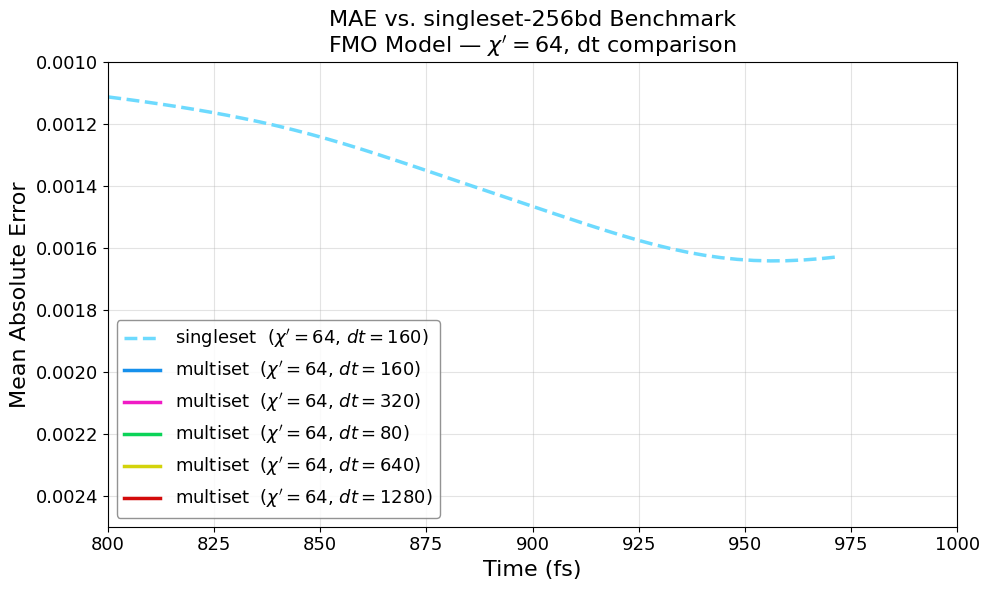

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_fmo_error_64bd_dt_comparison(left_=None,right_=None,top_=None,bottom_=None):
    """
    Compare MAE of singleset/multiset at chi'=64 with different dt,
    all against singleset_256bd benchmark.
    """

    test_dir = "."
    benchmark_file = os.path.join(test_dir, "singleset_256bd.xlsx")

    # Per-file config: (dt_au, label, color, linestyle, linewidth)
    file_configs = [
        ("singleset_64bd.xlsx",       160, "singleset  ($\\chi'=64$, $dt=160$)",        "#6ddafe", "--", 2.5),
        ("multiset_64bd.xlsx",        160, "multiset  ($\\chi'=64$, $dt=160$)",          "#1690ec", "-",  2.5),
        ("multiset_64bd_320dt.xlsx",  320, "multiset  ($\\chi'=64$, $dt=320$)",          "#f01bc5", "-",  2.5),
        ("multiset_64bd_80dt.xlsx",  160, "multiset  ($\\chi'=64$, $dt=80$)",          "#0bd358", "-",  2.5),
        ("multiset_64bd_640dt.xlsx",  640, "multiset  ($\\chi'=64$, $dt=640$)",          "#d3d30b", "-",  2.5),
        ("multiset_64bd_1280dt.xlsx",  1280, "multiset  ($\\chi'=64$, $dt=1280$)",          "#d30b0b", "-",  2.5),
    ]

    AU2FS = 0.024188843265

    # Read benchmark (use 160 dt axis)
    df_bm = pd.read_excel(benchmark_file, header=None)
    n_col = df_bm.shape[1]
    y_bm  = df_bm.iloc[:, :n_col].to_numpy(dtype=float)
    x_bm  = np.arange(len(y_bm)) * (160 * AU2FS)

    fig, ax = plt.subplots(figsize=(10, 6))

    for fname, dt_au, label, color, ls, lw in file_configs:
        fpath = os.path.join(test_dir, fname)
        if not os.path.exists(fpath):
            print(f"  [skip] {fpath}")
            continue

        dt = dt_au * AU2FS
        df_pred = pd.read_excel(fpath, header=None)
        y_pred  = df_pred.iloc[:, :n_col].to_numpy(dtype=float)
        x_pred  = np.arange(len(y_pred)) * dt

        y_bm_interp = np.column_stack([
            np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
        ])
        mae = np.mean(np.abs(y_pred - y_bm_interp), axis=1)

        ax.plot(x_pred, mae, label=label, color=color, linestyle=ls, linewidth=lw)
        print(f"  {label}: {len(y_pred)} steps, max MAE={mae.max():.4e}, mean MAE={mae.mean():.4e}")

    ax.set_xlabel("Time (fs)", fontsize=16)
    ax.set_ylabel("Mean Absolute Error", fontsize=16)
    ax.set_title("MAE vs. singleset-256bd Benchmark\nFMO Model — $\\chi'=64$, dt comparison", fontsize=16)
    ax.set_xlim(left=left_, right=right_)
    ax.set_ylim(bottom=bottom_,top=top_)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, framealpha=0.85, edgecolor="gray")
    ax.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.savefig("FMO_MAE_64bd_dt_comparison.png", dpi=150)
    print("\nSaved: FMO_MAE_64bd_dt_comparison.png")
    plt.show()


plot_fmo_error_64bd_dt_comparison()
plot_fmo_error_64bd_dt_comparison(left_=800,right_=1000,top_=0.001,bottom_=0.00025)


## PLOT RMSD

[Warning] 文件未找到，已跳过：multiset_256bd.xlsx


/tmp/ipykernel_197218/592354497.py:27: RuntimeWarning: invalid value encountered in sqrt
  rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))


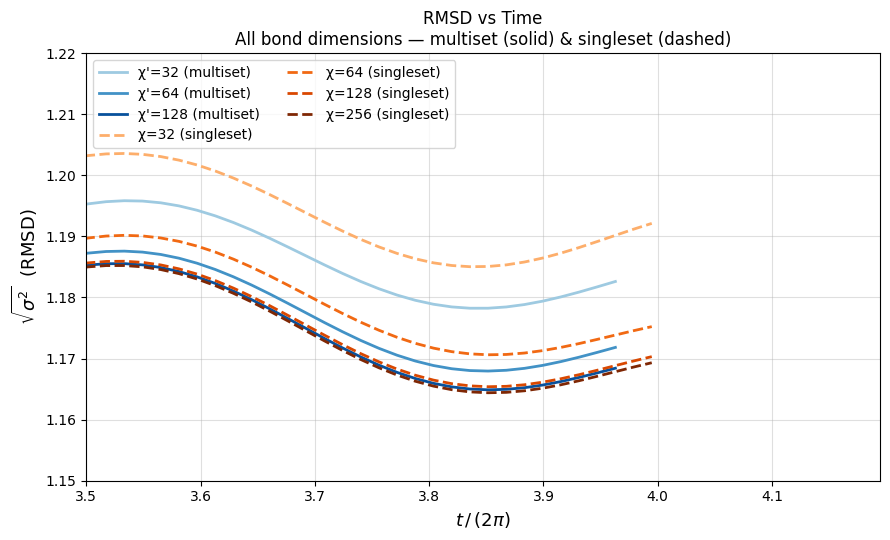

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本参数
# =========================
dt = 0.1  # a.u.

# =========================
# 计算 RMSD 的函数
# =========================
def compute_rmsd(file_path):
    df = pd.read_excel(file_path, header=None)
    occup = df.values  # shape: (Nt, Nsite)

    Nt, Nsite = occup.shape
    n0 = (Nsite - 1) / 2
    x = np.arange(Nsite)

    rmsd = np.zeros(Nt)
    for t in range(Nt):
        rho = occup[t]
        norm = np.sum(rho)
        if norm > 0:
            rho = rho / norm
        rmsd[t] = np.sqrt(np.sum((x - n0)**2 * rho))

    time_au = np.arange(Nt) * dt
    time_scaled = time_au / (2 * np.pi)
    return time_scaled, rmsd

# =========================
# 收集所有涉及的文件（去重），并标注来源组
# =========================

# multiset 组所有文件（按 bond dim 从小到大）
files_multiset = [
    ("χ'=32",   "multiset_32bd.xlsx"),
    ("χ'=64",  "multiset_64bd.xlsx"),
    ("χ'=128",  "multiset_128bd.xlsx"),
    ("χ'=256",  "multiset_256bd.xlsx"),   # 作为 χ'=32 的参考，也画出来
]

# singleset 组所有文件（按 bond dim 从小到大）
files_singleset = [
    ("χ=32",   "singleset_32bd.xlsx"),
    ("χ=64",   "singleset_64bd.xlsx"),
    ("χ=128",   "singleset_128bd.xlsx"),
    ("χ=256",  "singleset_256bd.xlsx"),  # 作为 χ=64 的参考，也画出来
]

# =========================
# 颜色配置
# multiset:  实线，蓝绿色系，bond dim 从小到大颜色从浅到深
# singleset: 虚线，橙红色系，bond dim 从小到大颜色从浅到深
# =========================
colors_multiset  = ["#9ecae1", "#4292c6", "#08519c", "#08145a"]  # 浅蓝→深蓝
colors_singleset = ["#fdae6b", "#f16913", "#d94801", "#7f2704"]  # 浅橙→深橙

# =========================
# 绘图：所有文件的 RMSD
# =========================
fig, ax = plt.subplots(figsize=(9, 5.5))

# --- multiset 组（实线）---
for (label, file_path), color in zip(files_multiset, colors_multiset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="-", color=color, label=f"{label} (multiset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# --- singleset 组（虚线）---
for (label, file_path), color in zip(files_singleset, colors_singleset):
    try:
        time, rmsd = compute_rmsd(file_path)
        ax.plot(time, rmsd, lw=2, ls="--", color=color, label=f"{label} (singleset)")
    except FileNotFoundError:
        print(f"[Warning] 文件未找到，已跳过：{file_path}")

# =========================
# 图像设置
# =========================
ax.set_xlim(left=3.5)
ax.set_ylim(bottom=1.15,top=1.22)
ax.set_xlabel(r"$t\,/\,(2\pi)$", fontsize=13)
ax.set_ylabel(r"$\sqrt{\sigma^2}$  (RMSD)", fontsize=13)
ax.set_title("RMSD vs Time\n"
             "All bond dimensions — multiset (solid) & singleset (dashed)",
             fontsize=12)
ax.legend(fontsize=10, ncol=2, loc="upper left")
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
# plt.savefig("All_RMSD.png", dpi=150)
plt.show()